In [4]:
%pip install pandas numpy requests matplotlib datetime


[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


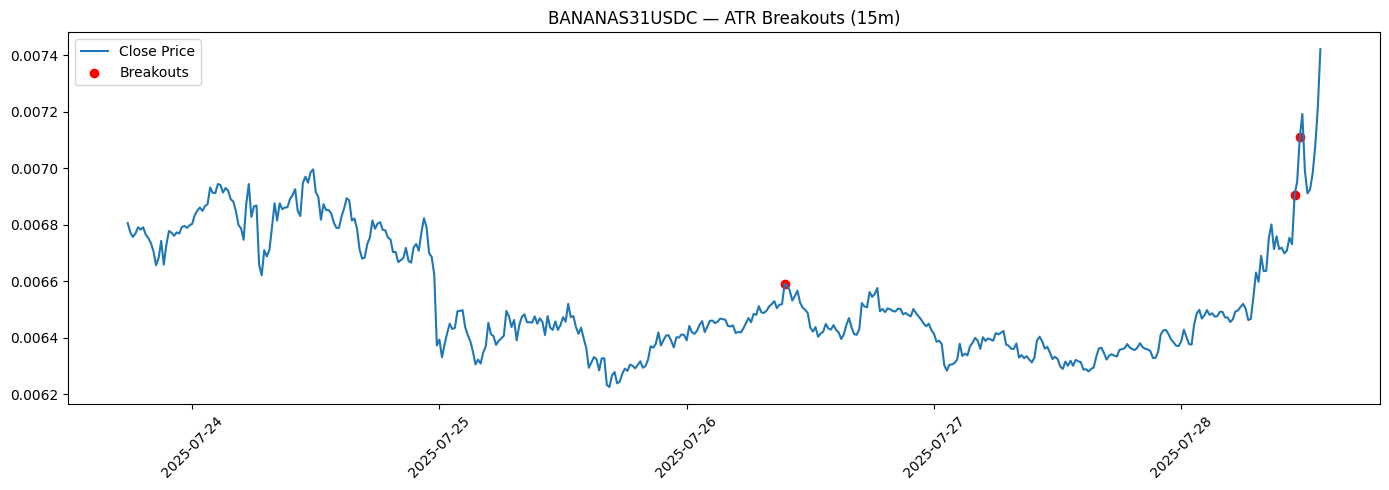

                        close       ATR  rolling_high  breakout_strength  \
open_time                                                                  
2025-07-26 09:30:00  0.006590  0.000029      0.006535           1.916376   
2025-07-28 11:00:00  0.006906  0.000067      0.006828           1.158416   
2025-07-28 11:30:00  0.007109  0.000077      0.007021           1.146331   

                     amplitude  
open_time                       
2025-07-26 09:30:00   0.000078  
2025-07-28 11:00:00   0.000189  
2025-07-28 11:30:00   0.000179  


In [ ]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
from datetime import datetime, timezone, timedelta

# Convert datetime to milliseconds since epoch
def to_ms(dt):
    return int(dt.timestamp() * 1000)

# Parameters
symbol = "BANANAS31USDC"
interval = "15m"
end_time = datetime.now(tz=timezone.utc)
start_time = end_time - timedelta(minutes=15*500)
start_time = to_ms(start_time)
# end_time = to_ms(end_time)
end_time = 1753710200000

# Fetch data in chunks (max 1500 candles per request)
def fetch_binance_klines(symbol, interval, start_ms, end_ms):
    url = "https://api.binance.com/api/v3/uiKlines"
    all_data = []
    while start_ms < end_ms:
        params = {
            "symbol": symbol,
            "interval": interval,
            "startTime": start_ms,
            "endTime": end_ms,
            "limit": 1000
        }
        resp = requests.get(url, params=params)
        data = resp.json()
        if not data:
            break
        all_data.extend(data)
        last_close = data[-1][0]
        start_ms = last_close + 1  # Prevent duplication
    return all_data

# Fetch and format data
raw_data = fetch_binance_klines(symbol, interval, start_time, end_time)
df = pd.DataFrame(raw_data, columns=[
    "open_time", "open", "high", "low", "close", "volume",
    "close_time", "quote_asset_volume", "num_trades",
    "taker_buy_base_vol", "taker_buy_quote_vol", "ignore"
])
df["open_time"] = pd.to_datetime(df["open_time"], unit="ms")
df.set_index("open_time", inplace=True)
df[["open", "high", "low", "close", "volume"]] = df[["open", "high", "low", "close", "volume"]].astype(float)

# ATR breakout logic
tr = pd.concat([
    df["high"] - df["low"],
    (df["high"] - df["close"].shift()).abs(),
    (df["low"] - df["close"].shift()).abs()
], axis=1).max(axis=1)

# Amplitude calculation (high - low)
df["amplitude"] = df["high"] - df["low"]

df["ATR"] = tr.rolling(window=30, min_periods=20).mean()
df["rolling_high"] = df["high"].rolling(window=30).max().shift(1)
df["breakout_strength"] = (df["close"] - df["rolling_high"]) / df["ATR"]
df["ATR_breakout"] = (df["close"] > (df["rolling_high"] + 1.1 * df["ATR"])) & (df["breakout_strength"] > 0.05)

# Plot close and breakouts
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["close"], label="Close Price")
plt.scatter(df[df["ATR_breakout"]].index, df[df["ATR_breakout"]]["close"], color='red', label="Breakouts")
plt.title(f"{symbol} — ATR Breakouts (15m)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Show breakout rows
print(df[df["ATR_breakout"]][["close", "ATR", "rolling_high", "breakout_strength", "amplitude"]].tail(10))